# Ablation 01: Classical GNN (Graph-based) vs CNN

**Research claim:** Converting images to graphs and classifying with a classical GNN
outperforms a parameter-matched CNN on the same task.

**Design:**
- **Model A — Classical GNN:** the same patch-based image-to-graph pipeline as GQMoE,
  but classification is done by a plain multi-layer GNN + global attention pooling + MLP head.
  No quantum router, no MoE, no iterative refinement.
- **Model B — CNN:** a standard convolutional network that sees the raw pixel grid directly.

This isolates the benefit of the *graph representation itself*, independent of the quantum
or MoE components that sit on top in the full GQMoE model.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR    = '/content/drive/MyDrive/GQMoE'
ABLATION_DIR = f'{DRIVE_DIR}/ablations/01_gnn_vs_cnn'
DATA_DIR     = f'{DRIVE_DIR}/data'
os.makedirs(ABLATION_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
requirements_path = f"{DRIVE_DIR}/requirements.txt"
!pip install -r "{requirements_path}"

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 32.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 59.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 36.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 146.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 

In [ ]:
import os, json, torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader as TorchDataLoader
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import (
    knn_graph, global_mean_pool, GlobalAttention,
    GCNConv, GATConv, SAGEConv, GINConv,
)
from torchvision import transforms
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

torch.manual_seed(42)
np.random.seed(42)


In [ ]:
config = {
    "file_path":     f"{DATA_DIR}/octmnist.npz",
    # Graph construction
    "patch_size":    7,     # 28×28 image → 16 patches of 7×7 pixels each
    "k_neighbors":   3,     # each patch node connects to its 3 nearest neighbors
    # GNN architecture
    "gnn_hidden":    128,   # hidden dim inside each GNN layer
    "gnn_layers":    3,     # number of message-passing layers
    "gnn_type":      "GCN", # backbone: one of GCN | GAT | SAGE | GIN
    # Shared classifier head
    "n_classes":     4,
    "clf_hidden":    256,
    "dropout":       0.3,
    # Training
    "batch_size":    32,
    "epochs":        50,
    "warmup_epochs": 5,
    "lr":            1e-3,
    "weight_decay":  1e-4,
    # Augmentation (training only)
    "aug_hflip":     True,
    "aug_vflip":     True,
    "aug_rotation":  15,
}


## Data Pipeline

`MedMNISTGraphPipeline` is identical to the one used in the full GQMoE model:
each image is divided into non-overlapping patches, and a k-NN graph is built from
patch feature similarity.  This is the *only* transformation before the GNN sees the data.

The CNN receives the raw pixel tensor — no patching, no graph construction.

In [ ]:
class MedMNISTGraphPipeline:
    """Convert a (C,H,W) image tensor into a PyG Data graph via patch-based nodes."""
    def __init__(self, patch_size, k_neighbors):
        self.patch_size   = patch_size
        self.k_neighbors  = k_neighbors

    def extract_patches(self, img: torch.Tensor) -> torch.Tensor:
        c, h, w = img.shape
        p = self.patch_size
        assert h % p == 0 and w % p == 0, f"Image size {h}×{w} not divisible by patch_size {p}"
        patches = img.unfold(1, p, p).unfold(2, p, p)        # [C, H/p, W/p, p, p]
        n = patches.shape[1] * patches.shape[2]               # total patches
        patches = patches.contiguous().view(c, n, p * p)
        patches = patches.permute(1, 0, 2).reshape(n, -1)     # [n, C*p*p]
        return patches

    def process(self, img: torch.Tensor) -> Data:
        x          = self.extract_patches(img)                # [n_nodes, node_dim]
        edge_index = knn_graph(x, k=self.k_neighbors, loop=False)
        return Data(x=x, edge_index=edge_index)


In [ ]:
def build_transform(cfg):
    augs = []
    if cfg.get("aug_hflip"):         augs.append(transforms.RandomHorizontalFlip(p=0.5))
    if cfg.get("aug_vflip"):         augs.append(transforms.RandomVerticalFlip(p=0.5))
    if cfg.get("aug_rotation", 0) > 0:
        augs.append(transforms.RandomRotation(degrees=cfg["aug_rotation"]))
    return transforms.Compose(augs) if augs else None


class GraphDataset(Dataset):
    """MedMNIST .npz → PyG graph per sample."""
    def __init__(self, npz_path, split, pipeline, transform=None):
        self.pipeline  = pipeline
        self.transform = transform
        d = np.load(npz_path)
        self.images = d[f'{split}_images']
        self.labels = d[f'{split}_labels']

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img   = torch.from_numpy(self.images[idx]).float().permute(2, 0, 1) / 255.0
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        graph = self.pipeline.process(img)
        lv    = label.item() if label.size == 1 else label[0]
        graph.y = torch.tensor([lv], dtype=torch.long)
        return graph


class ImageDataset(Dataset):
    """MedMNIST .npz → raw (C,H,W) tensor per sample for the CNN."""
    def __init__(self, npz_path, split, transform=None):
        self.transform = transform
        d = np.load(npz_path)
        self.images = d[f'{split}_images']
        self.labels = d[f'{split}_labels']

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img   = torch.from_numpy(self.images[idx]).float().permute(2, 0, 1) / 255.0
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        lv = label.item() if label.size == 1 else label[0]
        return img, torch.tensor(lv, dtype=torch.long)


In [ ]:
pipeline = MedMNISTGraphPipeline(config["patch_size"], config["k_neighbors"])
tf       = build_transform(config)

# GNN loaders (PyG DataLoader)
gnn_train_loader = PyGDataLoader(GraphDataset(config["file_path"], 'train', pipeline, tf),  config["batch_size"], shuffle=True)
gnn_val_loader   = PyGDataLoader(GraphDataset(config["file_path"], 'val',   pipeline),       config["batch_size"], shuffle=False)
gnn_test_loader  = PyGDataLoader(GraphDataset(config["file_path"], 'test',  pipeline),       config["batch_size"], shuffle=False)

# CNN loaders (standard DataLoader)
cnn_train_loader = TorchDataLoader(ImageDataset(config["file_path"], 'train', tf),  config["batch_size"], shuffle=True)
cnn_val_loader   = TorchDataLoader(ImageDataset(config["file_path"], 'val'),         config["batch_size"], shuffle=False)
cnn_test_loader  = TorchDataLoader(ImageDataset(config["file_path"], 'test'),        config["batch_size"], shuffle=False)

# Derive node feature dimension from data
sample      = next(iter(gnn_train_loader))
node_dim    = sample.x.shape[1]    # C * patch_size^2
n_patches   = (28 // config["patch_size"]) ** 2

print(f"patch_size:  {config['patch_size']}×{config['patch_size']}")
print(f"n_nodes:     {n_patches} patches per image")
print(f"node_dim:    {node_dim}  (3 channels × {config['patch_size']}² pixels)")
print(f"k_neighbors: {config['k_neighbors']}")


patch_size:  7×7
n_nodes:     16 patches per image
node_dim:    147  (3 channels × 7² pixels)
k_neighbors: 3


## Model A: Classical GNN Classifier

A stack of `gnn_layers` message-passing layers (configurable as GCN / GAT / SAGE / GIN),
followed by **GlobalAttention pooling** and a two-layer MLP head.

This architecture uses the exact same graph-structured input as GQMoE, but replaces the
quantum router and MoE with a single deterministic GNN backbone — making it the cleanest
possible classical graph baseline.

In [ ]:
class ClassicalGNNClassifier(nn.Module):
    """Multi-layer GNN → GlobalAttention pooling → MLP classifier.

    Supports four interchangeable backbones: GCN, GAT, SAGE, GIN.
    All share the same training loop and evaluation code."""

    SUPPORTED = ("GCN", "GAT", "SAGE", "GIN")

    def __init__(self, node_dim: int, hidden: int, n_layers: int,
                 n_classes: int, clf_hidden: int, dropout: float,
                 gnn_type: str = "GCN"):
        super().__init__()
        assert gnn_type in self.SUPPORTED, f"gnn_type must be one of {self.SUPPORTED}"
        self.gnn_type = gnn_type

        # ── Message-passing layers ─────────────────────────────────────────
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        in_dim = node_dim
        for i in range(n_layers):
            out_dim = hidden
            if gnn_type == "GCN":
                self.convs.append(GCNConv(in_dim, out_dim))
            elif gnn_type == "GAT":
                heads = 4
                # Intermediate layers concatenate heads; last layer averages
                concat = (i < n_layers - 1)
                self.convs.append(
                    GATConv(in_dim, out_dim // heads if concat else out_dim,
                            heads=heads, concat=concat))
                if concat: out_dim = out_dim  # heads are concatenated → same hidden dim
            elif gnn_type == "SAGE":
                self.convs.append(SAGEConv(in_dim, out_dim))
            elif gnn_type == "GIN":
                mlp = nn.Sequential(
                    nn.Linear(in_dim, out_dim), nn.ReLU(),
                    nn.Linear(out_dim, out_dim))
                self.convs.append(GINConv(mlp))
            self.norms.append(nn.LayerNorm(out_dim))
            in_dim = out_dim

        # ── Graph-level readout: GlobalAttention pooling ───────────────────
        gate_nn = nn.Sequential(
            nn.Linear(in_dim, clf_hidden), nn.ReLU(),
            nn.Linear(clf_hidden, 1))
        self.pool = GlobalAttention(gate_nn=gate_nn)

        # ── MLP classification head ────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, clf_hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(clf_hidden, n_classes))

    def forward(self, batch_data) -> torch.Tensor:
        x, edge_index, batch = batch_data.x, batch_data.edge_index, batch_data.batch
        for conv, norm in zip(self.convs, self.norms):
            x = norm(F.relu(conv(x, edge_index)))
        graph_vec = self.pool(x, batch)       # [B, hidden]
        return self.classifier(graph_vec)     # [B, n_classes]


## Model B: CNN Baseline

A standard convolutional network with three conv-BN-ReLU blocks + adaptive average pooling,
matching the GNN in parameter count as closely as possible.
The CNN sees the raw 28×28 pixel grid — no patch decomposition, no graph.

In [ ]:
class CNNClassifier(nn.Module):
    """Three-block CNN baseline for 28×28 MedMNIST images."""
    def __init__(self, in_channels: int = 3, n_classes: int = 8,
                 clf_hidden: int = 256, dropout: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 28×28 → 14×14
            nn.Conv2d(in_channels, 32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32,          64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: 14×14 → 7×7
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: 7×7 → 3×3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 3)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, clf_hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(clf_hidden, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


In [ ]:
gnn_model = ClassicalGNNClassifier(
    node_dim   = node_dim,
    hidden     = config["gnn_hidden"],
    n_layers   = config["gnn_layers"],
    n_classes  = config["n_classes"],
    clf_hidden = config["clf_hidden"],
    dropout    = config["dropout"],
    gnn_type   = config["gnn_type"],
)
cnn_model = CNNClassifier(
    in_channels = 3,
    n_classes   = config["n_classes"],
    clf_hidden  = config["clf_hidden"],
    dropout     = config["dropout"],
)

gnn_params = sum(p.numel() for p in gnn_model.parameters())
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f"GNN ({config['gnn_type']}) parameters: {gnn_params:,}")
print(f"CNN parameters:               {cnn_params:,}")
print(f"Parameter ratio (GNN/CNN):    {gnn_params/cnn_params:.2f}×")


GNN (GCN) parameters: 120,326
CNN parameters:               1,128,581
Parameter ratio (GNN/CNN):    0.11×


/tmp/ipykernel_501/1051340328.py:46: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate_nn)


## Training & Evaluation

In [ ]:
def make_scheduler(optimizer, cfg):
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1e-3, end_factor=1.0, total_iters=cfg["warmup_epochs"])
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg["epochs"] - cfg["warmup_epochs"])
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine], milestones=[cfg["warmup_epochs"]])


@torch.no_grad()
def evaluate_graph(model, loader, criterion, device):
    """Evaluate a graph model (PyG DataLoader)."""
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_probs, all_labs = [], []
    for batch in loader:
        batch  = batch.to(device)
        logits = model(batch)
        labels = batch.y.squeeze()
        loss_sum += criterion(logits, labels).item() * batch.num_graphs
        correct  += (logits.argmax(-1) == labels).sum().item()
        total    += batch.num_graphs
        all_probs.append(torch.softmax(logits, -1).cpu())
        all_labs.append(labels.cpu())
    probs = torch.cat(all_probs).numpy()
    labs  = torch.cat(all_labs).numpy()
    auc   = roc_auc_score(labs, probs, multi_class="ovr", average="macro") if len(np.unique(labs)) > 1 else float("nan")
    return loss_sum / total, correct / total, auc


@torch.no_grad()
def evaluate_cnn(model, loader, criterion, device):
    """Evaluate a CNN model (standard DataLoader)."""
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_probs, all_labs = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss_sum += criterion(logits, labels).item() * imgs.size(0)
        correct  += (logits.argmax(-1) == labels).sum().item()
        total    += imgs.size(0)
        all_probs.append(torch.softmax(logits, -1).cpu())
        all_labs.append(labels.cpu())
    probs = torch.cat(all_probs).numpy()
    labs  = torch.cat(all_labs).numpy()
    auc   = roc_auc_score(labs, probs, multi_class="ovr", average="macro") if len(np.unique(labs)) > 1 else float("nan")
    return loss_sum / total, correct / total, auc


def train_graph_model(model, train_loader, val_loader, cfg, run_name, save_dir):
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = make_scheduler(optimizer, cfg)
    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}
    best_acc  = 0.0

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        t_loss, correct, total = 0.0, 0, 0
        for batch in train_loader:
            batch  = batch.to(device)
            optimizer.zero_grad()
            logits = model(batch)
            labels = batch.y.squeeze()
            loss   = criterion(logits, labels)
            loss.backward(); optimizer.step()
            t_loss  += loss.item() * batch.num_graphs
            correct += (logits.argmax(-1) == labels).sum().item()
            total   += batch.num_graphs
        scheduler.step()
        t_acc = correct / total; t_loss /= total
        v_loss, v_acc, v_auc = evaluate_graph(model, val_loader, criterion, device)
        history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc);   history["val_acc"].append(v_acc)
        history["val_auc"].append(v_auc)
        if v_acc > best_acc:
            best_acc = v_acc
            torch.save(model.state_dict(), f"{save_dir}/best_{run_name}.pt")
        if epoch % 10 == 0 or epoch == cfg["epochs"]:
            print(f"[{run_name}] Epoch {epoch:03d} | val acc {v_acc:.4f}  auc {v_auc:.4f}")

    with open(f"{save_dir}/history_{run_name}.json", "w") as f:
        json.dump(history, f)
    return history


def train_cnn_model(model, train_loader, val_loader, cfg, run_name, save_dir):
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = make_scheduler(optimizer, cfg)
    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}
    best_acc  = 0.0

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        t_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward(); optimizer.step()
            t_loss  += loss.item() * imgs.size(0)
            correct += (logits.argmax(-1) == labels).sum().item()
            total   += imgs.size(0)
        scheduler.step()
        t_acc = correct / total; t_loss /= total
        v_loss, v_acc, v_auc = evaluate_cnn(model, val_loader, criterion, device)
        history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc);   history["val_acc"].append(v_acc)
        history["val_auc"].append(v_auc)
        if v_acc > best_acc:
            best_acc = v_acc
            torch.save(model.state_dict(), f"{save_dir}/best_{run_name}.pt")
        if epoch % 10 == 0 or epoch == cfg["epochs"]:
            print(f"[{run_name}] Epoch {epoch:03d} | val acc {v_acc:.4f}  auc {v_auc:.4f}")

    with open(f"{save_dir}/history_{run_name}.json", "w") as f:
        json.dump(history, f)
    return history


## Run Training

In [ ]:
print(f"=== Training Classical GNN ({config['gnn_type']}, {config['gnn_layers']} layers) ===")
history_gnn = train_graph_model(
    gnn_model, gnn_train_loader, gnn_val_loader,
    config, run_name="gnn", save_dir=ABLATION_DIR)

print("\n=== Training CNN Baseline ===")
history_cnn = train_cnn_model(
    cnn_model, cnn_train_loader, cnn_val_loader,
    config, run_name="cnn", save_dir=ABLATION_DIR)


=== Training Classical GNN (GCN, 3 layers) ===
[gnn] Epoch 010 | val acc 0.5750  auc 0.8166
[gnn] Epoch 020 | val acc 0.5500  auc 0.8179
[gnn] Epoch 030 | val acc 0.5583  auc 0.8197
[gnn] Epoch 040 | val acc 0.6000  auc 0.8332
[gnn] Epoch 050 | val acc 0.5833  auc 0.8271

=== Training CNN Baseline ===
[cnn] Epoch 010 | val acc 0.5750  auc 0.8213
[cnn] Epoch 020 | val acc 0.5667  auc 0.7912
[cnn] Epoch 030 | val acc 0.5917  auc 0.7991
[cnn] Epoch 040 | val acc 0.5500  auc 0.7858
[cnn] Epoch 050 | val acc 0.5667  auc 0.7894


## Test Evaluation

In [ ]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

gnn_model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_gnn.pt", map_location=device))
_, gnn_test_acc, gnn_test_auc = evaluate_graph(gnn_model.to(device), gnn_test_loader, criterion, device)

cnn_model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_cnn.pt", map_location=device))
_, cnn_test_acc, cnn_test_auc = evaluate_cnn(cnn_model.to(device), cnn_test_loader, criterion, device)

print(f"{'Model':<30} {'Params':>10} {'Test Acc':>10} {'Macro AUC':>12}")
print("-" * 64)
print(f"{'Classical GNN (' + config['gnn_type'] + ')':<30} {gnn_params:>10,} {gnn_test_acc*100:>9.2f}% {gnn_test_auc:>12.4f}")
print(f"{'CNN Baseline':<30} {cnn_params:>10,} {cnn_test_acc*100:>9.2f}% {cnn_test_auc:>12.4f}")
print()
print(f"Δ Accuracy  (GNN − CNN):  {(gnn_test_acc - cnn_test_acc)*100:+.2f}%")
print(f"Δ AUC       (GNN − CNN):  {gnn_test_auc - cnn_test_auc:+.4f}")


Model                              Params   Test Acc    Macro AUC
----------------------------------------------------------------
Classical GNN (GCN)               120,326     53.25%       0.7425
CNN Baseline                    1,128,581     51.75%       0.7417

Δ Accuracy  (GNN − CNN):  +1.50%
Δ AUC       (GNN − CNN):  +0.0008


## Per-class Classification Report

In [ ]:
def collect_preds(model, loader, device, is_graph=True):
    model.eval(); preds, labs = [], []
    with torch.no_grad():
        if is_graph:
            for b in loader:
                b = b.to(device); preds += model(b).argmax(-1).cpu().tolist()
                labs  += b.y.squeeze().cpu().tolist()
        else:
            for imgs, labels in loader:
                imgs = imgs.to(device); preds += model(imgs).argmax(-1).cpu().tolist()
                labs  += labels.tolist()
    return preds, labs

gnn_preds, gnn_labs = collect_preds(gnn_model, gnn_test_loader, device, is_graph=True)
cnn_preds, cnn_labs = collect_preds(cnn_model, cnn_test_loader, device, is_graph=False)

class_names = [f"Class {i}" for i in range(config["n_classes"])]
print("=== Classical GNN Classification Report ===")
print(classification_report(gnn_labs, gnn_preds, target_names=class_names))
print("=== CNN Classification Report ===")
print(classification_report(cnn_labs, cnn_preds, target_names=class_names))


=== Classical GNN Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.77      0.76      0.77       174
     Class 1       0.18      0.04      0.07        46
     Class 2       0.42      0.35      0.38        92
     Class 3       0.33      0.69      0.45        68
     Class 4       0.00      0.00      0.00        20

    accuracy                           0.53       400
   macro avg       0.34      0.37      0.33       400
weighted avg       0.51      0.53      0.50       400

=== CNN Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.75      0.77      0.76       174
     Class 1       0.20      0.13      0.16        46
     Class 2       0.36      0.40      0.38        92
     Class 3       0.34      0.44      0.38        68
     Class 4       0.00      0.00      0.00        20

    accuracy                           0.52       400
   macro avg       0.33      0.35      0.34       400

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## Visualization

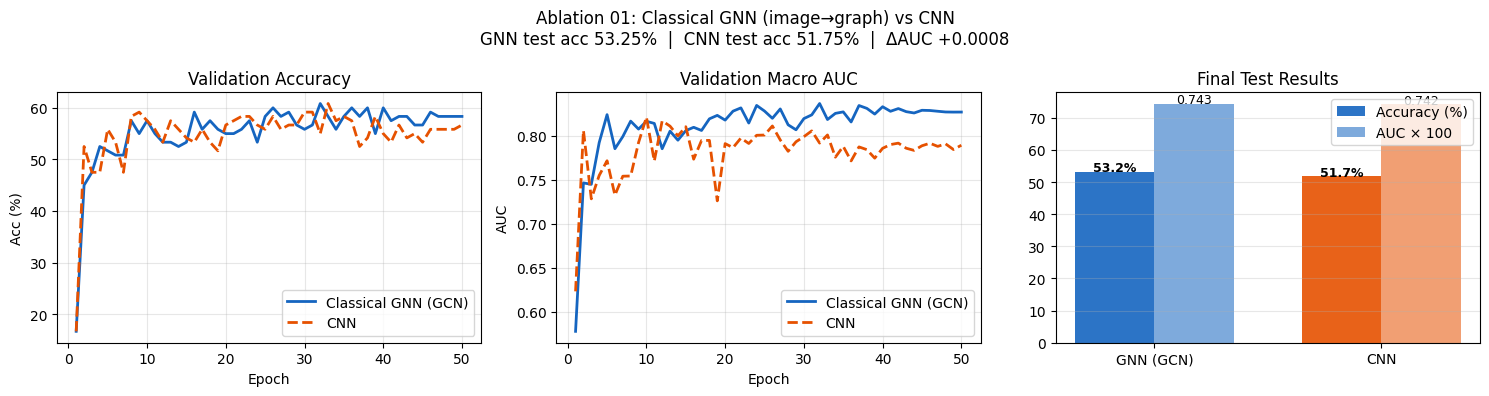

Saved to /content/drive/MyDrive/GQMoE/ablations/01_gnn_vs_cnn/ablation01_results.png


In [ ]:
epochs = range(1, config["epochs"] + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
gnn_color, cnn_color = "#1565C0", "#E65100"

# ── Val Accuracy ──────────────────────────────────────────────────────────────
axes[0].plot(epochs, [a * 100 for a in history_gnn["val_acc"]], label=f"Classical GNN ({config['gnn_type']})", lw=2, color=gnn_color)
axes[0].plot(epochs, [a * 100 for a in history_cnn["val_acc"]], label="CNN",                                   lw=2, color=cnn_color, ls="--")
axes[0].set_title("Validation Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Acc (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── Val AUC ───────────────────────────────────────────────────────────────────
axes[1].plot(epochs, history_gnn["val_auc"], label=f"Classical GNN ({config['gnn_type']})", lw=2, color=gnn_color)
axes[1].plot(epochs, history_cnn["val_auc"], label="CNN",                                   lw=2, color=cnn_color, ls="--")
axes[1].set_title("Validation Macro AUC"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].legend(); axes[1].grid(alpha=0.3)

# ── Final test bar ────────────────────────────────────────────────────────────
model_labels = [f"GNN ({config['gnn_type']})", "CNN"]
accs = [gnn_test_acc * 100, cnn_test_acc * 100]
aucs = [gnn_test_auc * 100, cnn_test_auc * 100]
x, w = np.arange(2), 0.35
axes[2].bar(x - w/2, accs, width=w, color=[gnn_color, cnn_color], alpha=0.9,  label="Accuracy (%)")
axes[2].bar(x + w/2, aucs, width=w, color=[gnn_color, cnn_color], alpha=0.55, label="AUC × 100")
axes[2].set_xticks(x); axes[2].set_xticklabels(model_labels)
axes[2].set_title("Final Test Results"); axes[2].legend(); axes[2].grid(alpha=0.3, axis="y")
for j, (a, u) in enumerate(zip(accs, aucs)):
    axes[2].text(j - w/2, a + 0.2, f"{a:.1f}%", ha="center", fontsize=9, fontweight="bold")
    axes[2].text(j + w/2, u + 0.2, f"{u/100:.3f}", ha="center", fontsize=9)

plt.suptitle(
    f"Ablation 01: Classical GNN (image→graph) vs CNN\n"
    f"GNN test acc {gnn_test_acc*100:.2f}%  |  CNN test acc {cnn_test_acc*100:.2f}%  |  "
    f"ΔAUC {gnn_test_auc - cnn_test_auc:+.4f}",
    fontsize=12)
plt.tight_layout()
plt.savefig(f"{ABLATION_DIR}/ablation01_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {ABLATION_DIR}/ablation01_results.png")


## Optional: Sweep All GNN Backbone Types

Run all four GNN architectures (GCN, GAT, SAGE, GIN) and compare them together against the CNN.
Useful to confirm the advantage is consistent across GNN backbones, not specific to one.


=== GCN ===


/tmp/ipykernel_501/1051340328.py:46: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate_nn)


[gnn_gcn] Epoch 010 | val acc 0.5250  auc 0.8112
[gnn_gcn] Epoch 020 | val acc 0.5500  auc 0.8312
[gnn_gcn] Epoch 030 | val acc 0.5750  auc 0.8116
[gnn_gcn] Epoch 040 | val acc 0.5917  auc 0.8402
[gnn_gcn] Epoch 050 | val acc 0.5917  auc 0.8329
  Test acc 52.75%  AUC 0.7229

=== GAT ===


/tmp/ipykernel_501/1051340328.py:46: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate_nn)


[gnn_gat] Epoch 010 | val acc 0.5750  auc 0.8176
[gnn_gat] Epoch 020 | val acc 0.6000  auc 0.8246
[gnn_gat] Epoch 030 | val acc 0.5667  auc 0.8275
[gnn_gat] Epoch 040 | val acc 0.5833  auc 0.8159
[gnn_gat] Epoch 050 | val acc 0.5833  auc 0.8091
  Test acc 52.00%  AUC 0.7339

=== SAGE ===


/tmp/ipykernel_501/1051340328.py:46: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate_nn)


[gnn_sage] Epoch 010 | val acc 0.5333  auc 0.8061
[gnn_sage] Epoch 020 | val acc 0.5417  auc 0.8242
[gnn_sage] Epoch 030 | val acc 0.5333  auc 0.8261
[gnn_sage] Epoch 040 | val acc 0.5667  auc 0.8105
[gnn_sage] Epoch 050 | val acc 0.5583  auc 0.8192
  Test acc 56.00%  AUC 0.7426

=== GIN ===


/tmp/ipykernel_501/1051340328.py:46: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=gate_nn)


[gnn_gin] Epoch 010 | val acc 0.5667  auc 0.7984
[gnn_gin] Epoch 020 | val acc 0.5667  auc 0.8074
[gnn_gin] Epoch 030 | val acc 0.5833  auc 0.8105
[gnn_gin] Epoch 040 | val acc 0.5833  auc 0.8129
[gnn_gin] Epoch 050 | val acc 0.5917  auc 0.8258
  Test acc 53.25%  AUC 0.7422


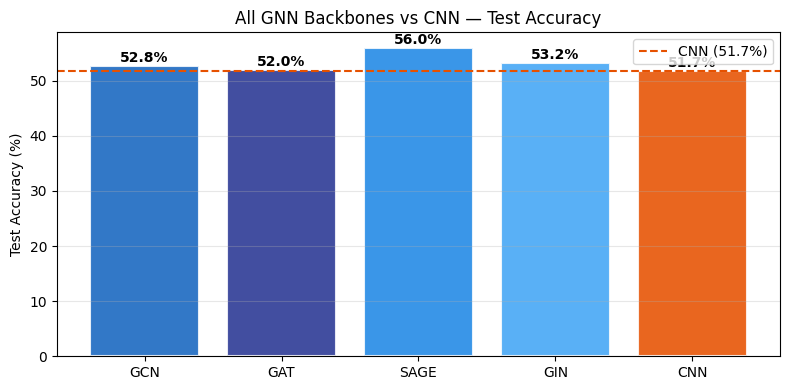

In [ ]:
GNN_TYPES = ["GCN", "GAT", "SAGE", "GIN"]
sweep_results = {}

for gnn_type in GNN_TYPES:
    print(f"\n=== {gnn_type} ===")
    model = ClassicalGNNClassifier(
        node_dim=node_dim, hidden=config["gnn_hidden"], n_layers=config["gnn_layers"],
        n_classes=config["n_classes"], clf_hidden=config["clf_hidden"],
        dropout=config["dropout"], gnn_type=gnn_type)
    hist = train_graph_model(model, gnn_train_loader, gnn_val_loader,
                              config, run_name=f"gnn_{gnn_type.lower()}", save_dir=ABLATION_DIR)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_gnn_{gnn_type.lower()}.pt", map_location=device))
    _, ta, tau = evaluate_graph(model.to(device), gnn_test_loader, nn.CrossEntropyLoss(), device)
    sweep_results[gnn_type] = {"acc": ta, "auc": tau, "history": hist}
    print(f"  Test acc {ta*100:.2f}%  AUC {tau:.4f}")

# ── Sweep summary bar plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
all_names = GNN_TYPES + ["CNN"]
all_accs  = [sweep_results[t]["acc"] * 100 for t in GNN_TYPES] + [cnn_test_acc * 100]
sweep_colors = ["#1565C0","#283593","#1E88E5","#42A5F5", cnn_color]
bars = ax.bar(range(len(all_names)), all_accs, color=sweep_colors, alpha=0.88, edgecolor="white", linewidth=1.5)
ax.set_xticks(range(len(all_names))); ax.set_xticklabels(all_names)
ax.set_ylabel("Test Accuracy (%)"); ax.set_title("All GNN Backbones vs CNN — Test Accuracy")
ax.grid(alpha=0.3, axis="y")
for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
# Draw reference line at CNN accuracy
ax.axhline(cnn_test_acc * 100, ls="--", color=cnn_color, lw=1.5, label=f"CNN ({cnn_test_acc*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{ABLATION_DIR}/ablation01_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
